# Dependencies import

In [1]:
!pip install git+https://github.com/WildlifeDatasets/wildlife-datasets@develop
!pip install git+https://github.com/WildlifeDatasets/wildlife-tools

  Cloning https://github.com/WildlifeDatasets/wildlife-datasets (to revision develop) to /tmp/pip-req-build-poi98b4d
  Running command git clone --filter=blob:none --quiet https://github.com/WildlifeDatasets/wildlife-datasets /tmp/pip-req-build-poi98b4d
  Running command git checkout -b develop --track origin/develop
  Switched to a new branch 'develop'
  Branch 'develop' set up to track remote branch 'develop' from 'origin'.
  Resolved https://github.com/WildlifeDatasets/wildlife-datasets to commit 753d9bf64861c3e17011136b3436bf58bf02317f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 1.3 MB/s eta 0:00:00a 0:00:01
  Created wheel for wildlife-datasets: filename=wildlife_datasets-1.0.6-py3-none-any.whl size=88078 sha256=2a4e3bdddca5a0b4b2093e672a33d39595e4f3342eeab05351d5d9cc02cf0f0e
  Stored in directory: /tmp/pip-ephem-wheel-cache-fo_nhlsb

In [31]:
!rm -r /kaggle/working/logs

In [5]:
! ls /kaggle/working

dataset		  saved_models_v12  saved_models_v16  saved_variables.pkl
saved_models_v10  saved_models_v13  saved_models_v8   saved_variables_v13.pkl
saved_models_v11  saved_models_v14  saved_models_v9   state.db


In [6]:
# In Kaggle notebook, first save your files as a dataset
#!kaggle datasets init -p /kaggle/working/saved_models_v13/best_model.pth
#!kaggle datasets create -p /kaggle/working/saved_models_v13/best_model.pth

# Then locally:
#! kaggle datasets download zhtmgxr/saved_model_13

In [2]:
import numpy as np
from typing import List, Union
import os
import numpy as np
import pandas as pd
import timm
import torchvision.transforms as T
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm import tqdm
from wildlife_datasets.datasets import AnimalCLEF2025
from wildlife_tools.features import DeepFeatures
from wildlife_tools.similarity import CosineSimilarity

def baks_compute(
        y_true: Union[List, np.ndarray],
        y_pred: Union[List, np.ndarray],
        identity_test_only: Union[List, np.ndarray]
    ) -> float:
    """Computes BAKS (balanced accuracy on known samples).
    
    Focuses only on samples with known identities (not in identity_test_only).
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        identity_test_only: Labels of unknown identities (only in test set)
        
    Returns:
        Balanced accuracy score for known samples
    """
    # Convert inputs to numpy arrays with object dtype to handle mixed types
    y_true = np.array(y_true, dtype=object)
    y_pred = np.array(y_pred, dtype=object)
    identity_test_only = np.array(identity_test_only, dtype=object)
    
    # Filter out unknown samples
    mask = ~np.isin(y_true, identity_test_only)
    y_true_known = y_true[mask]
    y_pred_known = y_pred[mask]
    
    if len(y_true_known) == 0:
        return 0.0
    
    # Get unique classes in the filtered true labels
    unique_classes = np.unique(y_true_known)
    n_classes = len(unique_classes)
    
    # Compute per-class accuracy and average
    class_accuracies = []
    for cls in unique_classes:
        cls_mask = (y_true_known == cls)
        if np.sum(cls_mask) > 0:
            cls_acc = np.mean(y_pred_known[cls_mask] == cls)
            class_accuracies.append(cls_acc)
    
    # Return the balanced accuracy (mean of per-class accuracies)
    return np.mean(class_accuracies) if class_accuracies else 0.0

def baus_compute(
        y_true: Union[List, np.ndarray],
        y_pred: Union[List, np.ndarray],
        identity_test_only: Union[List, np.ndarray],
        new_class: Union[int, str]
    ) -> float:
    """Computes BAUS (balanced accuracy on unknown samples).
    
    Focuses only on samples with unknown identities (in identity_test_only).
    
    Args:
        y_true: True labels
        y_pred: Predicted labels
        identity_test_only: Labels of unknown identities (only in test set)
        new_class: Label used for identifying unknown samples
        
    Returns:
        Balanced accuracy score for unknown samples
    """
    # Convert inputs to numpy arrays with object dtype to handle mixed types
    y_true = np.array(y_true, dtype=object)
    y_pred = np.array(y_pred, dtype=object)
    identity_test_only = np.array(identity_test_only, dtype=object)
    
    # Filter to include only unknown samples
    mask = np.isin(y_true, identity_test_only)
    y_true_unknown = y_true[mask]
    y_pred_unknown = y_pred[mask]
    
    if len(y_true_unknown) == 0:
        return 0.0
    
    # Get unique unknown classes
    unique_unknown_classes = np.unique(y_true_unknown)
    
    # For each unknown class, check if they were correctly predicted as new_class
    class_accuracies = []
    for cls in unique_unknown_classes:
        cls_mask = (y_true_unknown == cls)
        if np.sum(cls_mask) > 0:
            # For unknown samples, correct prediction is new_class
            cls_acc = np.mean(y_pred_unknown[cls_mask] == new_class)
            class_accuracies.append(cls_acc)
    
    # Return the balanced accuracy (mean of per-class accuracies)
    return np.mean(class_accuracies) if class_accuracies else 0.0


def compute_geometric_mean(baks, baus):
    return np.sqrt(baks * baus)


def create_sample_submission(dataset_query, predictions, file_name='sample_submission.csv'):
    df = pd.DataFrame({
        'image_id': dataset_query.metadata['image_id'],
        'identity': predictions
    })
    df.to_csv(file_name, index=False)
    
root = '/kaggle/input/animal-clef-2025'
import cv2
import numpy as np
from PIL import Image
class GammaCorrection(object):
    """
    Gamma校正增强的Transform实现
    """
    def __init__(self, gamma=1.0):
        self.gamma = gamma
        self.inv_gamma = 1.0 / gamma
        self.table = np.array([((i / 255.0) ** self.inv_gamma) * 255
                             for i in np.arange(0, 256)]).astype("uint8")
    
    def __call__(self, img):
        # 将PIL图像转换为numpy数组
        img_np = np.array(img)
        # 应用gamma校正
        img_corrected = cv2.LUT(img_np, self.table)
        # 转回PIL图像
        return Image.fromarray(img_corrected)
class ImgAugTransform:
    def __init__(self):
        self.aug = iaa.Sequential([
            iaa.Fliplr(p=0.5),
            iaa.Flipud(p=0.5),
            iaa.GaussianBlur(sigma=(0.0, 0.1)),
            iaa.MultiplyBrightness(mul=(0.65, 1.35)),        
            iaa.Sometimes(0.4,
                iaa.Affine(
                    rotate=(-30, 30),
                    mode='constant',
                    cval=0
                )
            ),
        ])

    def __call__(self, img):
        # Convert PIL Image to numpy array
        img_np = np.array(img)
        # Apply imgaug transformations
        img_aug = self.aug.augment_image(img_np)
        # Convert back to PIL Image
        return Image.fromarray(img_aug)

# 修改transform
transform = T.Compose([
    T.Resize([384, 384]),
    #CLAHE(clip_limit=2.0, tile_grid_size=(8,8)),  # 添加CLAHE
    GammaCorrection(gamma=0.5),  # 添加Gamma校正
    #ImgAugTransform(),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# 对于display transform，我们也可以添加这些增强
transform_display = T.Compose([
    T.Resize([384, 384]),
    #CLAHE(clip_limit=2.0, tile_grid_size=(8,8)),
    GammaCorrection(gamma=0.5),
    #ImgAugTransform()
])



2025-05-05 02:03:22.027652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746410602.212434      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746410602.266070      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Split dataset

In [14]:
! ls /kaggle/working/dataset

images	new_metadata.csv


In [4]:
#! cp -r /kaggle/input/offline-imgaug/aug /kaggle/working/dataset
#! mv /kaggle/working/dataset/new_metadata.csv /kaggle/working/dataset/metadata.csv

In [ ]:
# assign id
import pandas as pd

# 1. 读取metadata.csv
df = pd.read_csv("/kaggle/input/offline-imgaug/aug/metadata.csv")

# 2. 添加image_id列（从0开始的连续整数）
df["image_id"] = range(len(df))

# 3. 保存修改后的DataFrame（覆盖原文件或保存为新文件）
# 选项1: 直接覆盖原文件
df.to_csv("/kaggle/input/offline-imgaug/aug/metadata.csv", index=False)

In [3]:
from sklearn.preprocessing import LabelEncoder
root = '/kaggle/input/offline-imgaug/aug'
# Loading the dataset
dataset = AnimalCLEF2025(root, transform=None, load_label=True)
# data fillna
dataset.metadata.loc[dataset.metadata['species'].isna(), 'species'] = 'salamander'
dataset_database = dataset.get_subset(dataset.metadata['split'] == 'database')
dataset_query = dataset.get_subset(dataset.metadata['split'] == 'query')
n_query = len(dataset_query)

In [4]:
# transform label
df_database = dataset_database.df
df_database['name'] = df_database['identity'].copy()
encoder = LabelEncoder()
df_database['identity'] = encoder.fit_transform(df_database['identity'])
dataset_database.df = df_database

In [5]:
# split
# availableSet & testSet
from wildlife_datasets import splits
openSplitter = splits.OpenSetSplit(0.9, 0.1, seed=333)
for idx_train, idx_test in openSplitter.split(df_database):
    splits.analyze_split(df_database, idx_train, idx_test)
df_train, df_test = df_database.loc[idx_train], df_database.loc[idx_test]
availableSet = dataset_database.get_subset(df_train.index)
testSet = dataset_database.get_subset(df_test.index)
df_availableSet = availableSet.df

# trainSet & thresholdSet
openSplitter = splits.OpenSetSplit(0.9, 0.1, seed=333)
for idx_train, idx_test in openSplitter.split(df_availableSet):
    splits.analyze_split(df_availableSet, idx_train, idx_test)
df_train, df_test = df_availableSet.loc[idx_train], df_availableSet.loc[idx_test]
trainSet = availableSet.get_subset(df_train.index)
thresholdSet = availableSet.get_subset(df_test.index)
df_database_training = trainSet.df

# training & test 
closeSplitter = splits.ClosedSetSplit(0.9, seed=333)
for idx_train, idx_test in closeSplitter.split(df_database_training):
    splits.analyze_split(df_database_training, idx_train, idx_test)
df_training, df_val = df_database_training.loc[idx_train], df_database_training.loc[idx_test]
training = trainSet.get_subset(df_training.index)
test = trainSet.get_subset(df_val.index)

Split: time-unaware open-set
Samples: train/test/unassigned/total = 12399/2492/0/14891
Classes: train/test/unassigned/total = 1002/1102/0/1102
Samples: train only/test only        = 0/1490
Classes: train only/test only/joint  = 0/100/1002

Fraction of train set     = 83.27%
Fraction of test set only = 10.01%
Split: time-unaware open-set
Samples: train/test/unassigned/total = 10244/2155/0/12399
Classes: train/test/unassigned/total = 912/1002/0/1002
Samples: train only/test only        = 0/1243
Classes: train only/test only/joint  = 0/90/912

Fraction of train set     = 82.62%
Fraction of test set only = 10.03%
Split: time-unaware closed-set
Samples: train/test/unassigned/total = 8802/1442/0/10244
Classes: train/test/unassigned/total = 912/912/0/912
Samples: train only/test only        = 0/0
Classes: train only/test only/joint  = 0/0/912

Fraction of train set     = 85.92%
Fraction of test set only = 0.00%


In [6]:
# check
testSet.df.dataset.value_counts()

dataset
SeaTurtleID2022     1204
SalamanderID2025     815
LynxID2025           473
Name: count, dtype: int64

In [7]:
# check
def analyze_new_individuals(test_df, available_df):
    """分析测试集中每个物种的新个体（不在可用集中的个体）及其图片数量"""
    # 获取可用集中的所有个体ID
    available_individuals = set(available_df['identity'].unique())
    
    # 在测试集中标记哪些个体是新的（不在可用集中）
    test_df['is_new_individual'] = ~test_df['identity'].isin(available_individuals)
    
    # 按物种分组统计新个体的图片数量
    analysis = test_df[test_df['is_new_individual']].groupby('species').agg(
        new_individuals=('identity', 'nunique'),
        new_images=('image_id', 'count')
    ).reset_index()
    
    return analysis

# 运行分析
new_species_analysis = analyze_new_individuals(testSet.df, availableSet.df)

# 打印结果
print("各物种的新个体和图片统计:")
print(new_species_analysis.to_string(index=False))

各物种的新个体和图片统计:
          species  new_individuals  new_images
loggerhead turtle               37         803
             lynx                7         403
       salamander               56         284


In [8]:
df_database

,image_id,identity,path,date,orientation,species,split,dataset,name
0,0,29,images/LynxID2025/database/0.jpg,NaN,right,lynx,database,LynxID2025,LynxID2025_lynx_37
1,1,29,images/LynxID2025/database/1.jpg,NaN,left,lynx,database,LynxID2025,LynxID2025_lynx_37
2,2,40,images/LynxID2025/database/2.jpg,NaN,left,lynx,database,LynxID2025,LynxID2025_lynx_49
3,4,11,images/LynxID2025/database/4.jpg,NaN,right,lynx,database,LynxID2025,LynxID2025_lynx_13
4,6,7,images/LynxID2025/database/6.jpg,NaN,left,lynx,database,LynxID2025,LynxID2025_lynx_07
...,...,...,...,...,...,...,...,...,...
14886,17021,618,images/SalamanderID2025/database/images/17021.jpg,2024-10-02,top,salamander,database,SalamanderID2025,SalamanderID2025_647
14887,17022,473,images/SalamanderID2025/database/images/17022.jpg,2023-09-22,right,salamander,database,SalamanderID2025,SalamanderID2025_507
14888,17023,473,images/SalamanderID2025/database/images/17023.jpg,2023-09-22,right,salamander,database,SalamanderID2025,SalamanderID2025_507
14889,17024,473,images/SalamanderID2025/database/images/17024.jpg,2023-09-22,right,salamander,database,SalamanderID2025,SalamanderID2025_507


In [21]:
# to DataLoader
class AnimalReIDDataset(Dataset):
    def __init__(self, dataloader, transform=None):
        self.dataloader = dataloader
        self.transform = transform
        self.identity_to_idx = {id_: idx for idx, id_ in enumerate(dataloader.metadata['identity'].unique())} # one identity got one index as its label
        
    def __len__(self):
        return len(self.dataloader)
    
    def __getitem__(self, idx):
        img, _ = self.dataloader[idx]
        identity = self.dataloader.metadata.iloc[idx]['identity']
        label = self.identity_to_idx[identity]
        
        if self.transform:
            img = self.transform(img)
        
        return img, label

# 2. 创建数据加载器
batch_size = 64
train_dataset = AnimalReIDDataset(training,transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataset_1 = AnimalReIDDataset(test,transform)
val_dataloader_1 = DataLoader(val_dataset_1, batch_size=batch_size, shuffle=True, num_workers=2)

# 打印训练集中的个体数量
num_classes = len(training.metadata['identity'].unique())
print(f"训练集中共有{num_classes}个不同的个体")


训练集中共有912个不同的个体


In [22]:
# Get one batch
for batch in train_loader:
    images, labels = batch
    break  # Stop after the first batch

print("Label shape:", labels.shape)
print("Sample labels:", labels[:5])  # First 5 labels in the batch

for idx in [0, 1, 2, 3, 4]:
    img, label = train_dataset[idx]
    print(f"Index {idx}: Label {label}")
print(num_classes)

Label shape: torch.Size([64])
Sample labels: tensor([294, 875, 714, 785, 637])
Index 0: Label 0
Index 1: Label 0
Index 2: Label 0
Index 3: Label 1
Index 4: Label 1
912


# Train model

In [23]:
import random
import torch
import numpy as np

def set_seed(seed=1):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# 设置随机种子
set_seed(1)

In [24]:
# prepare fine-tuning
model_name = 'hf-hub:BVRA/MegaDescriptor-L-384'
model = timm.create_model(model_name, pretrained=True)
model.train(False) 
# 冻结所有层
for param in model.parameters():
    param.requires_grad = False

# 解冻关键层
for name, param in model.named_parameters():
    # 解冻最后两个阶段
    if 'layers.3' in name:  # Stage3和Stage2
        param.requires_grad = True
    #if "layers.2.blocks.17" in name:
        #param.requires_grad = True
    #if "layers.2.blocks.16" in name:
        #param.requires_grad = True
    # 解冻分类头
    if name == 'fc.weight' or name == 'fc.bias':  
        param.requires_grad = True
    # 解冻最后的LayerNorm
    if name == 'norm.weight' or name == 'norm.bias':  # 最终归一化层
        param.requires_grad = True

# 验证可训练参数
print("可训练参数:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"- {name}")


可训练参数:
- layers.3.downsample.norm.weight
- layers.3.downsample.norm.bias
- layers.3.downsample.reduction.weight
- layers.3.blocks.0.norm1.weight
- layers.3.blocks.0.norm1.bias
- layers.3.blocks.0.attn.relative_position_bias_table
- layers.3.blocks.0.attn.qkv.weight
- layers.3.blocks.0.attn.qkv.bias
- layers.3.blocks.0.attn.proj.weight
- layers.3.blocks.0.attn.proj.bias
- layers.3.blocks.0.norm2.weight
- layers.3.blocks.0.norm2.bias
- layers.3.blocks.0.mlp.fc1.weight
- layers.3.blocks.0.mlp.fc1.bias
- layers.3.blocks.0.mlp.fc2.weight
- layers.3.blocks.0.mlp.fc2.bias
- layers.3.blocks.1.norm1.weight
- layers.3.blocks.1.norm1.bias
- layers.3.blocks.1.attn.relative_position_bias_table
- layers.3.blocks.1.attn.qkv.weight
- layers.3.blocks.1.attn.qkv.bias
- layers.3.blocks.1.attn.proj.weight
- layers.3.blocks.1.attn.proj.bias
- layers.3.blocks.1.norm2.weight
- layers.3.blocks.1.norm2.bias
- layers.3.blocks.1.mlp.fc1.weight
- layers.3.blocks.1.mlp.fc1.bias
- layers.3.blocks.1.mlp.fc2.weight
-

In [25]:
print(model)

SwinTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
    (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (layers): Sequential(
    (0): SwinTransformerStage(
      (downsample): Identity()
      (blocks): Sequential(
        (0): SwinTransformerBlock(
          (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (attn): WindowAttention(
            (qkv): Linear(in_features=192, out_features=576, bias=True)
            (attn_drop): Dropout(p=0.0, inplace=False)
            (proj): Linear(in_features=192, out_features=192, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
            (softmax): Softmax(dim=-1)
          )
          (drop_path1): Identity()
          (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
          (mlp): Mlp(
            (fc1): Linear(in_features=192, out_features=768, bias=True)
            (act): GELU(approximate='none')
            (

In [26]:
##Remove the original classifier
#original_fc = model.get_classifier()
#input_features = original_fc.in_features if hasattr(original_fc, 'in_features') else model.num_features
#model.reset_classifier(0)

# Add the new ResNet block as the classifier
model.head.drop = nn.Dropout(p=0.33)
model.head.fc = nn.Linear(1536, 912)
#model.head.fc = nn.Sequential(
    #nn.Flatten(1), 
    #nn.LayerNorm(1536),
    #nn.Dropout(0.3),
    #nn.Linear(1536, 512),
    #nn.GELU(),
    #nn.Linear(512, 912)
    #nn.Linear(1536, 912)
#)
# Move the model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [27]:
print("可训练参数:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"- {name}")

可训练参数:
- layers.3.downsample.norm.weight
- layers.3.downsample.norm.bias
- layers.3.downsample.reduction.weight
- layers.3.blocks.0.norm1.weight
- layers.3.blocks.0.norm1.bias
- layers.3.blocks.0.attn.relative_position_bias_table
- layers.3.blocks.0.attn.qkv.weight
- layers.3.blocks.0.attn.qkv.bias
- layers.3.blocks.0.attn.proj.weight
- layers.3.blocks.0.attn.proj.bias
- layers.3.blocks.0.norm2.weight
- layers.3.blocks.0.norm2.bias
- layers.3.blocks.0.mlp.fc1.weight
- layers.3.blocks.0.mlp.fc1.bias
- layers.3.blocks.0.mlp.fc2.weight
- layers.3.blocks.0.mlp.fc2.bias
- layers.3.blocks.1.norm1.weight
- layers.3.blocks.1.norm1.bias
- layers.3.blocks.1.attn.relative_position_bias_table
- layers.3.blocks.1.attn.qkv.weight
- layers.3.blocks.1.attn.qkv.bias
- layers.3.blocks.1.attn.proj.weight
- layers.3.blocks.1.attn.proj.bias
- layers.3.blocks.1.norm2.weight
- layers.3.blocks.1.norm2.bias
- layers.3.blocks.1.mlp.fc1.weight
- layers.3.blocks.1.mlp.fc1.bias
- layers.3.blocks.1.mlp.fc2.weight
-

In [20]:
#! pip install git+https://github.com/KellerJordan/Muon

  Cloning https://github.com/KellerJordan/Muon to /tmp/pip-req-build-073u0g72
  Running command git clone --filter=blob:none --quiet https://github.com/KellerJordan/Muon /tmp/pip-req-build-073u0g72
  Resolved https://github.com/KellerJordan/Muon to commit 12dc5336852ec10fbe1a1119ad09c92d2d81505e
  Preparing metadata (setup.py) ... done
  Created wheel for muon: filename=muon-0.1.0-py3-none-any.whl size=6075 sha256=302ece4431e084a9dc0193068a2b8b58f07bf7a15633a4aeefd6d64c491536fd
  Stored in directory: /tmp/pip-ephem-wheel-cache-97wkla5c/wheels/1a/2a/a3/61ecbf3ca51b145e323667d7d04223983322960049887b1d5f
Successfully built muon


# Muon cannot be used since distributed GPU is needed

In [19]:
from muon import Muon

# 1. Parameter grouping - matches your previous structure
muon_params = []

# Muon gets all 2D+ parameters from layers[3]
for name, param in model.layers[3].named_parameters():
    if param.ndim >= 2:  # Weight matrices only
        muon_params.append(param)

# AdamW gets other parameters (matching your previous groups)
adamw_groups = [
    {'params': [p for p in model.layers[3].parameters() if p.ndim < 2]},  # Fixed: Added closing } for dict
    {'params': model.head.fc.parameters(), 'lr': 5e-5},
    {'params': model.norm.parameters(), 'lr': 1e-5}
]

# 2. Create optimizers with your exact previous settings
optimizers = [
    Muon(
        muon_params,
        lr=5e-5,  # Matches your layers[3] LR
        momentum=0.95,
        rank=0,
        world_size=1
    ),
    torch.optim.AdamW(
        adamw_groups,
        lr=5e-5,  # Base LR (will be overridden by per-group LRs)
        betas=(0.9, 0.999),  # Default AdamW betas
        weight_decay=0.05  # Matches your previous
    )
]

In [29]:
# training parameters
criterion = nn.CrossEntropyLoss()
from torch.optim.lr_scheduler import CosineAnnealingLR


optimizer = torch.optim.AdamW([
    {'params': model.layers[3].parameters(), 'lr': 5e-5},  # Use [3] instead of .3
    {'params': model.head.fc.parameters(), 'lr': 5e-5},
    {'params': model.norm.parameters(), 'lr': 1e-5}
], weight_decay=0.05)  # Commas between dictionaries are correct

#scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2, verbose=True, min_lr=1e-6)
num_epochs = 20
#scheduler = CosineAnnealingLR(
#    optimizer,          # 你的优化器（或optimizers[0]如果是Muon+AdamW混合）
#    T_max=num_epochs,   # 半周期epoch数（通常=总epoch数）
#    eta_min=1e-6,       # 最小学习率（默认0）
#    last_epoch=-1
#)


In [30]:
# 导入TensorBoard相关库
from torch.utils.tensorboard import SummaryWriter
import os
from tqdm import tqdm
# model13: learning rate head: 1e3-> 1e5, batch32
# model14: batch size 32 -> 64, scheduler added, lr 1e5 -> 5e5
# model15: batch size 64 -> 16, scheduler added
# model17: batch size 64, scheduler added, lr 5e5, layer2 16 17 blocks unfreezed
# model19: batch size 64, scheduler CosineAnnealingLR, lr 5e5, layer2 16 17 blocks unfreezed
# 创建日志和模型保存目录
kaggle_log_dir = os.path.join('/kaggle/working', 'logs', 'animal_md_ft_v14_batch64')
os.makedirs(kaggle_log_dir, exist_ok=True)
saved_models_dir = os.path.join('/kaggle/working', 'saved_models_v14')
os.makedirs(saved_models_dir, exist_ok=True)

writer = SummaryWriter(log_dir=kaggle_log_dir)
print(f"TensorBoard log directory: {kaggle_log_dir}")
print(f"Model save directory: {saved_models_dir}")

# 训练循环
best_model_state = None
best_loss = float('inf')
global_step = 0

# 记录初始状态
writer.add_scalar('Training/Start', 0, 0)
writer.flush()

for epoch in range(num_epochs):
    # 训练阶段
    model.train()
    running_train_loss = 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Train Epoch {epoch+1}/{num_epochs}')
    for batch_idx, (inputs, labels) in enumerate(progress_bar):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        #for i, param_group in enumerate(optimizer.param_groups):
        #    writer.add_scalar(f'LearningRate/group_{i}', param_group['lr'], epoch)
            # 同时打印到控制台
            #print(f'  Param Group {i} LR: {param_group["lr"]:.3e}')
            
        running_train_loss += loss.item()
        current_loss = loss.item()
        progress_bar.set_postfix({'loss': current_loss})
        
        writer.add_scalar('Training/BatchLoss', current_loss, global_step)
        
        if batch_idx % 100 == 0:
            writer.flush()
            print(f"[Train] Batch {batch_idx}, loss: {current_loss:.4f}, step: {global_step}")
        
        global_step += 1
    
    # 计算训练集平均损失
    train_epoch_loss = running_train_loss / len(train_loader)
    writer.add_scalar('Loss/Train', train_epoch_loss, epoch)
    
    # 测试阶段
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        test_progress = tqdm(val_dataloader_1, desc=f'Test Epoch {epoch+1}/{num_epochs}')
        for inputs, labels in test_progress:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item()
    
    # 计算测试集平均损失
    test_epoch_loss = running_test_loss / len(val_dataloader_1)
    writer.add_scalar('Loss/Test', test_epoch_loss, epoch)
    
    # 记录学习率
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('LearningRate', current_lr, epoch)
    scheduler.step(test_epoch_loss)
    
    # 打印epoch结果
    print(f'Epoch {epoch+1}/{num_epochs}, '
          f'Train Loss: {train_epoch_loss:.4f}, '
          f'Test Loss: {test_epoch_loss:.4f}, '
          f'LR: {current_lr:.6f}')
    
    # 保存当前epoch模型
    #epoch_model_path = os.path.join(saved_models_dir, f'model_epoch_{epoch+1}.pth')
    #torch.save(model.state_dict(), epoch_model_path)
    #print(f"Model saved to {epoch_model_path}")
    
    # 更新最佳模型
    if test_epoch_loss < best_loss:
        best_loss = test_epoch_loss
        best_model_state = model.state_dict().copy()
        best_model_path = os.path.join(saved_models_dir, 'best_model.pth')
        torch.save(best_model_state, best_model_path)
        print(f"New best model saved with test loss: {best_loss:.4f}")
    
    writer.flush()

# 关闭TensorBoard writer
writer.close()

# 加载最佳模型
model.load_state_dict(best_model_state)
print(f"训练完成！最佳测试损失: {best_loss:.4f}")
print(f"TensorBoard日志保存在: {kaggle_log_dir}")
print(f"模型保存在: {saved_models_dir}")
print("在Kaggle中查看TensorBoard:")
print(f"%tensorboard --logdir {kaggle_log_dir}")

TensorBoard log directory: /kaggle/working/logs/animal_md_ft_v14_batch64
Model save directory: /kaggle/working/saved_models_v14


Train Epoch 1/20:   1%|          | 1/138 [00:05<11:59,  5.25s/it, loss=6.9]

[Train] Batch 0, loss: 6.9047, step: 0


Train Epoch 1/20:  73%|███████▎  | 101/138 [05:15<01:54,  3.10s/it, loss=4.66]

[Train] Batch 100, loss: 4.6620, step: 100


...

[Train] Batch 0, loss: 0.3795, step: 2622


Train Epoch 20/20:  73%|███████▎  | 101/138 [05:14<01:54,  3.11s/it, loss=0.301]

[Train] Batch 100, loss: 0.3005, step: 2722


Test Epoch 20/20: 100%|██████████| 23/23 [01:03<00:00,  2.76s/it]

Epoch 20/20, Train Loss: 0.2899, Test Loss: 2.1038, LR: 0.000050
训练完成！最佳测试损失: 2.0988
TensorBoard日志保存在: /kaggle/working/logs/animal_md_ft_v14_batch64
模型保存在: /kaggle/working/saved_models_v14
在Kaggle中查看TensorBoard:
%tensorboard --logdir /kaggle/working/logs/animal_md_ft_v14_batch64


In [95]:
# continue to train
# 创建日志和模型保存目录
# 导入TensorBoard相关库
from torch.utils.tensorboard import SummaryWriter
import os
from tqdm import tqdm
kaggle_log_dir = os.path.join('/kaggle/working', 'logs', 'animal_md_ft_v14_batch64')
os.makedirs(kaggle_log_dir, exist_ok=True)
saved_models_dir = os.path.join('/kaggle/working', 'saved_models_v14')
os.makedirs(saved_models_dir, exist_ok=True)

writer = SummaryWriter(log_dir=kaggle_log_dir)
print(f"TensorBoard log directory: {kaggle_log_dir}")
print(f"Model save directory: {saved_models_dir}")

# 训练循环
model.load_state_dict(best_model_state)
start_epoch = 33
more_epochs = 7
#global_step  = 5444
#best_loss = 2.1107
for epoch in range(start_epoch, start_epoch + more_epochs):
    # 训练阶段
    model.train()
    running_train_loss = 0.0
    
    progress_bar = tqdm(train_loader, desc=f'Train Epoch {epoch+1}/{num_epochs+more_epochs}')
    for batch_idx, (inputs, labels) in enumerate(progress_bar):
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()
        current_loss = loss.item()
        progress_bar.set_postfix({'loss': current_loss})
        
        writer.add_scalar('Training/BatchLoss', current_loss, global_step)
        
        if batch_idx % 100 == 0:
            writer.flush()
            print(f"[Train] Batch {batch_idx}, loss: {current_loss:.4f}, step: {global_step}")
        
        global_step += 1
    
    # 计算训练集平均损失
    train_epoch_loss = running_train_loss / len(train_loader)
    writer.add_scalar('Loss/Train', train_epoch_loss, epoch)
    
    # 测试阶段
    model.eval()
    running_test_loss = 0.0
    with torch.no_grad():
        test_progress = tqdm(val_dataloader_1, desc=f'Test Epoch {epoch+1}/{num_epochs+more_epochs}')
        for inputs, labels in test_progress:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_test_loss += loss.item()
    
    # 计算测试集平均损失
    test_epoch_loss = running_test_loss / len(val_dataloader_1)
    writer.add_scalar('Loss/Test', test_epoch_loss, epoch)
    
    # 记录学习率
    current_lr = optimizer.param_groups[0]['lr']
    writer.add_scalar('LearningRate', current_lr, epoch)
    
    # 打印epoch结果
    print(f'Epoch {epoch+1}/{num_epochs}, '
          f'Train Loss: {train_epoch_loss:.4f}, '
          f'Test Loss: {test_epoch_loss:.4f}, '
          f'LR: {current_lr:.6f}')
    
    # 保存当前epoch模型
    #epoch_model_path = os.path.join(saved_models_dir, f'model_epoch_{epoch+1}.pth')
    #torch.save(model.state_dict(), epoch_model_path)
    #print(f"Model saved to {epoch_model_path}")
    
    # 更新最佳模型
    if test_epoch_loss < best_loss:
        best_loss = test_epoch_loss
        best_model_state = model.state_dict().copy()
        best_model_path = os.path.join(saved_models_dir, 'best_model.pth')
        torch.save(best_model_state, best_model_path)
        print(f"New best model saved with test loss: {best_loss:.4f}")
    
    writer.flush()

# 关闭TensorBoard writer
writer.close()

# 加载最佳模型
model.load_state_dict(best_model_state)
print(f"训练完成！最佳测试损失: {best_loss:.4f}")
print(f"TensorBoard日志保存在: {kaggle_log_dir}")
print(f"模型保存在: {saved_models_dir}")
print("在Kaggle中查看TensorBoard:")
print(f"%tensorboard --logdir {kaggle_log_dir}")

TensorBoard log directory: /kaggle/working/logs/animal_md_ft_v14_batch64
Model save directory: /kaggle/working/saved_models_v14


Train Epoch 34/27:   1%|          | 1/138 [00:04<10:37,  4.65s/it, loss=0.0595]

[Train] Batch 0, loss: 0.0595, step: 4554


Train Epoch 34/27:  73%|███████▎  | 101/138 [05:16<01:55,  3.13s/it, loss=0.0818]

[Train] Batch 100, loss: 0.0818, step: 4654


...

[Train] Batch 0, loss: 0.0539, step: 5382


Train Epoch 40/27:  73%|███████▎  | 101/138 [05:17<01:55,  3.13s/it, loss=0.22] 

[Train] Batch 100, loss: 0.2198, step: 5482


Test Epoch 40/27: 100%|██████████| 23/23 [01:04<00:00,  2.82s/it]

Epoch 40/20, Train Loss: 0.2049, Test Loss: 2.0833, LR: 0.000050
训练完成！最佳测试损失: 2.0717
TensorBoard日志保存在: /kaggle/working/logs/animal_md_ft_v14_batch64
模型保存在: /kaggle/working/saved_models_v14
在Kaggle中查看TensorBoard:
%tensorboard --logdir /kaggle/working/logs/animal_md_ft_v14_batch64


In [19]:
model.load_state_dict(torch.load('/kaggle/working/saved_models_v13/best_model.pth'))

/tmp/ipykernel_368/507125640.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/kaggle/working/saved_models_v13/best_model.pth'))


<All keys matched successfully>

In [20]:
best_model_state = model.state_dict().copy()

# Similarity calculation

In [ ]:
from wildlife_tools.similarity import CosineSimilarity
from wildlife_tools.similarity.wildfusion import SimilarityPipeline, WildFusion
from wildlife_tools.similarity.pairwise.lightglue import MatchLightGlue
from wildlife_tools.features.local import AlikedExtractor
from wildlife_tools.similarity.calibration import IsotonicCalibration

In [33]:
device = 'cuda'
transforms_aliked = T.Compose([
    T.Resize([512, 512]),
    GammaCorrection(gamma=0.5),
    T.ToTensor()
])
matcher_aliked = SimilarityPipeline(
    matcher = MatchLightGlue(features='aliked', device=device, batch_size=16),
    extractor = AlikedExtractor(),
    transform = transforms_aliked,
    calibration = IsotonicCalibration()
)

matcher_mega = SimilarityPipeline(
    matcher = CosineSimilarity(),
    extractor = DeepFeatures(model=model, device=device, batch_size=16),
    transform = transform,
    calibration = IsotonicCalibration()
)

/usr/local/lib/python3.11/dist-packages/lightglue/lightglue.py:24: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/aliked_lightglue.pth" to /root/.cache/torch/hub/checkpoints/aliked_lightglue_v0-1_arxiv.pth
100%|██████████| 45.4M/45.4M [00:00<00:00, 219MB/s]
Downloading: "https://github.com/Shiaoming/ALIKED/raw/main/models/aliked-n16.pth" to /root/.cache/torch/hub/checkpoints/aliked-n16.pth
100%|██████████| 2.61M/2.61M [00:00<00:00, 43.4MB/s]


In [34]:
dataset_calibration = AnimalCLEF2025(root, df=dataset_database.metadata[:100], load_label=True) 

In [35]:
dataset_calibration.df

,image_id,identity,path,date,orientation,species,split,dataset,name
0,0,29,images/LynxID2025/database/0.jpg,NaN,right,lynx,database,LynxID2025,LynxID2025_lynx_37
1,1,29,images/LynxID2025/database/1.jpg,NaN,left,lynx,database,LynxID2025,LynxID2025_lynx_37
2,2,40,images/LynxID2025/database/2.jpg,NaN,left,lynx,database,LynxID2025,LynxID2025_lynx_49
3,4,11,images/LynxID2025/database/4.jpg,NaN,right,lynx,database,LynxID2025,LynxID2025_lynx_13
4,6,7,images/LynxID2025/database/6.jpg,NaN,left,lynx,database,LynxID2025,LynxID2025_lynx_07
...,...,...,...,...,...,...,...,...,...
95,134,6,images/LynxID2025/database/134.jpg,NaN,unknown,lynx,database,LynxID2025,LynxID2025_lynx_06
96,135,3,images/LynxID2025/database/135.jpg,NaN,left,lynx,database,LynxID2025,LynxID2025_lynx_03
97,136,7,images/LynxID2025/database/136.jpg,NaN,left,lynx,database,LynxID2025,LynxID2025_lynx_07
98,138,36,images/LynxID2025/database/138.jpg,NaN,left,lynx,database,LynxID2025,LynxID2025_lynx_45


In [36]:
# Calibrating the WildFusion
wildfusion_submission = WildFusion(calibrated_pipelines = [matcher_aliked, matcher_mega], priority_pipeline = matcher_mega)
wildfusion_submission.fit_calibration(dataset_calibration, dataset_calibration)

100%|█████████████████████████████████████████████████████████████████| 7/7 [00:05<00:00,  1.33it/s]


In [37]:
# Compute WildFusion similarity
similarity = wildfusion_submission(thresholdSet, training, B=25)

100%|█████████████████████████████████████████████████████████████| 551/551 [06:19<00:00,  1.45it/s]


In [38]:
import pickle

# 定义要保存的变量（确保这些变量已正确生成）
save_data = {
    "similarity": similarity  # for thredsholdSet similarity
    #"wildfusion_submission": wildfusion_submission
}

# 保存到 Kaggle 工作目录
with open("/kaggle/working/saved_variables.pkl", "wb") as f:
    pickle.dump(save_data, f)

print("变量已保存到 /kaggle/working/saved_variables.pkl")

变量已保存到 /kaggle/working/saved_variables.pkl


In [39]:
similarity.shape

(2155, 8802)

# Prediction for thresholdTest

In [40]:
n_query = len(thresholdSet)
pred_idx_threshold = similarity.argsort(axis=1)[:,-1]
pred_scores_threshold = similarity[range(n_query), pred_idx_threshold]

In [41]:
pred_scores_threshold.shape

(2155,)

# Selecting threshold for 3 species respectively based on BAKS BAUS

In [42]:
# Get species indices
lynx_indices = thresholdSet.df[thresholdSet.df['species'] == 'lynx'].index
loggerhead_indices = thresholdSet.df[thresholdSet.df['species'] == 'loggerhead turtle'].index
salamander_indices = thresholdSet.df[thresholdSet.df['species'] == 'salamander'].index

# Get prediction indices
pred_idx_threshold_lynx = pred_idx_threshold[lynx_indices]
pred_idx_threshold_loggerhead = pred_idx_threshold[loggerhead_indices]
pred_idx_threshold_salamander = pred_idx_threshold[salamander_indices]

# Get prediction scores
pred_scores_threshold_lynx = pred_scores_threshold[lynx_indices]
pred_scores_threshold_loggerhead = pred_scores_threshold[loggerhead_indices]
pred_scores_threshold_salamander = pred_scores_threshold[salamander_indices]

In [43]:
unseen_ids_threshold = []
all_ids = df_database['identity'].unique()

for i in all_ids:
    if i in thresholdSet.metadata['identity'].tolist():
        if i not in training.metadata['identity'].tolist():
            # if not in the training set, the id in test set havent been seen before
            unseen_ids_threshold.append(i)

Evaluating Lynx:
Threshold: 0.10 | BAKS: 0.5000 | BAUS: 0.0000 | GEO_MEAN: 0.0000
Threshold: 0.15 | BAKS: 0.5000 | BAUS: 0.0000 | GEO_MEAN: 0.0000
Threshold: 0.20 | BAKS: 0.4848 | BAUS: 0.0049 | GEO_MEAN: 0.0488
Threshold: 0.25 | BAKS: 0.4848 | BAUS: 0.0390 | GEO_MEAN: 0.1374
Threshold: 0.30 | BAKS: 0.4848 | BAUS: 0.0430 | GEO_MEAN: 0.1444
Threshold: 0.35 | BAKS: 0.4848 | BAUS: 0.1202 | GEO_MEAN: 0.2415
Threshold: 0.40 | BAKS: 0.4697 | BAUS: 0.1464 | GEO_MEAN: 0.2622
Threshold: 0.45 | BAKS: 0.4545 | BAUS: 0.1932 | GEO_MEAN: 0.2964
Threshold: 0.50 | BAKS: 0.3788 | BAUS: 0.6067 | GEO_MEAN: 0.4794
Threshold: 0.55 | BAKS: 0.3030 | BAUS: 0.8355 | GEO_MEAN: 0.5032
Threshold: 0.60 | BAKS: 0.3030 | BAUS: 0.8877 | GEO_MEAN: 0.5187
Threshold: 0.65 | BAKS: 0.2727 | BAUS: 0.9602 | GEO_MEAN: 0.5117
Threshold: 0.70 | BAKS: 0.2727 | BAUS: 0.9631 | GEO_MEAN: 0.5125
Threshold: 0.75 | BAKS: 0.2576 | BAUS: 0.9842 | GEO_MEAN: 0.5035
Threshold: 0.80 | BAKS: 0.2424 | BAUS: 0.9922 | GEO_MEAN: 0.4904
Threshol

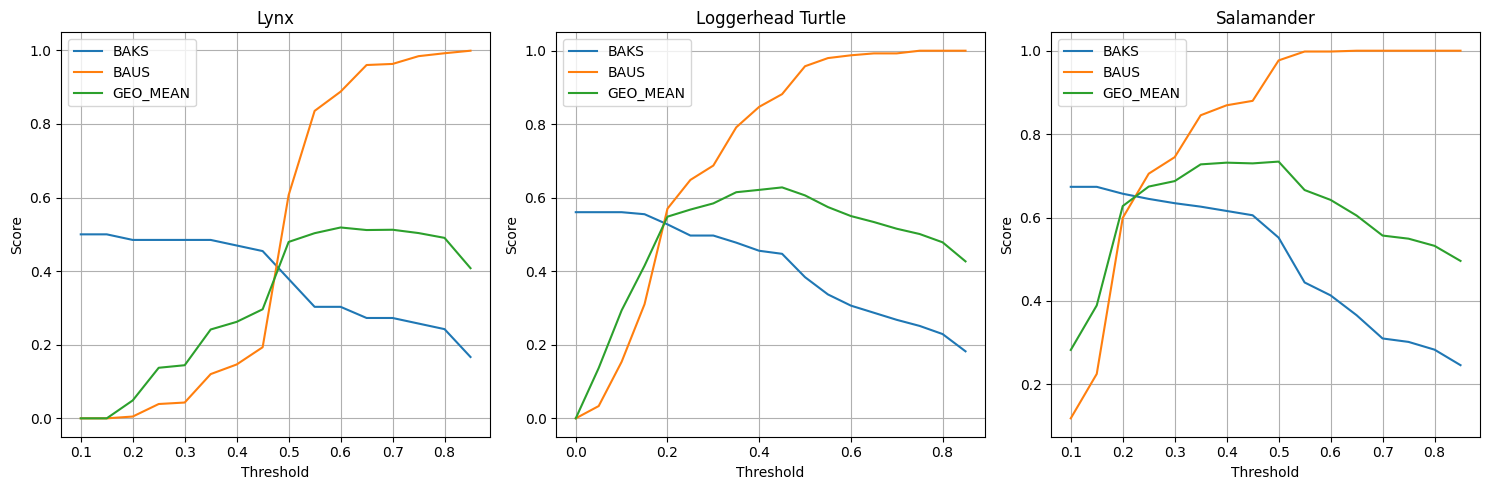

In [49]:
# First get the filtered labels for each species
thresholdSet_true_labels_lynx = thresholdSet_true_labels[lynx_indices]
thresholdSet_true_labels_loggerhead = thresholdSet_true_labels[loggerhead_indices]
thresholdSet_true_labels_salamander = thresholdSet_true_labels[salamander_indices]

# Filter unseen_ids for each species
unseen_ids_threshold_lynx =  [str(x) for x in unseen_ids_threshold]
unseen_ids_threshold_loggerhead =  [str(x) for x in unseen_ids_threshold]
unseen_ids_threshold_salamander =  [str(x) for x in unseen_ids_threshold]

# Version for Lynx
def evaluate_lynx_thresholds():
    thresholds = np.arange(0.1, 0.9, 0.05)
    results_lynx = []
    labels = np.array(training.labels_string)

    print("Evaluating Lynx:")
    for threshold in thresholds:
        predictions = labels[pred_idx_threshold_lynx].copy()
        predictions[pred_scores_threshold_lynx < threshold] = 'new_individual'

        baks = baks_compute(thresholdSet_true_labels_lynx, predictions, unseen_ids_threshold_lynx)
        baus = baus_compute(thresholdSet_true_labels_lynx, predictions, unseen_ids_threshold_lynx, 'new_individual')
        geo_mean = compute_geometric_mean(baks, baus)
        results_lynx.append((threshold, baks, baus, geo_mean))

        print(f"Threshold: {threshold:.2f} | BAKS: {baks:.4f} | BAUS: {baus:.4f} | GEO_MEAN: {geo_mean:.4f}")
    return results_lynx

# Version for Loggerhead Turtle
def evaluate_loggerhead_thresholds():
    thresholds = np.arange(0, 0.9, 0.05)
    results_loggerhead = []
    labels = np.array(training.labels_string)

    print("\nEvaluating Loggerhead Turtle:")
    for threshold in thresholds:
        predictions = labels[pred_idx_threshold_loggerhead].copy()
        predictions[pred_scores_threshold_loggerhead < threshold] = 'new_individual'

        baks = baks_compute(thresholdSet_true_labels_loggerhead, predictions, unseen_ids_threshold_loggerhead)
        baus = baus_compute(thresholdSet_true_labels_loggerhead, predictions, unseen_ids_threshold_loggerhead, 'new_individual')
        geo_mean = compute_geometric_mean(baks, baus)
        results_loggerhead.append((threshold, baks, baus, geo_mean))

        print(f"Threshold: {threshold:.2f} | BAKS: {baks:.4f} | BAUS: {baus:.4f} | GEO_MEAN: {geo_mean:.4f}")
    return results_loggerhead

# Version for Salamander
def evaluate_salamander_thresholds():
    thresholds = np.arange(0.1, 0.9, 0.05)
    results_salamander = []
    labels = np.array(training.labels_string)

    print("\nEvaluating Salamander:")
    for threshold in thresholds:
        predictions = labels[pred_idx_threshold_salamander].copy()
        predictions[pred_scores_threshold_salamander < threshold] = 'new_individual'

        baks = baks_compute(thresholdSet_true_labels_salamander, predictions, unseen_ids_threshold_salamander)
        baus = baus_compute(thresholdSet_true_labels_salamander, predictions, unseen_ids_threshold_salamander, 'new_individual')
        geo_mean = compute_geometric_mean(baks, baus)
        results_salamander.append((threshold, baks, baus, geo_mean))

        print(f"Threshold: {threshold:.2f} | BAKS: {baks:.4f} | BAUS: {baus:.4f} | GEO_MEAN: {geo_mean:.4f}")
    return results_salamander

# Run evaluations
results_lynx = evaluate_lynx_thresholds()
results_loggerhead = evaluate_loggerhead_thresholds()
results_salamander = evaluate_salamander_thresholds()

# Optional: Plot results for comparison
def plot_results(results_lynx, results_loggerhead, results_salamander):
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
    
    for results, ax, title in zip([results_lynx, results_loggerhead, results_salamander], 
                                [ax1, ax2, ax3],
                                ['Lynx', 'Loggerhead Turtle', 'Salamander']):
        thresholds = [r[0] for r in results]
        baks = [r[1] for r in results]
        baus = [r[2] for r in results]
        geo_mean = [r[3] for r in results]
        
        ax.plot(thresholds, baks, label='BAKS')
        ax.plot(thresholds, baus, label='BAUS')
        ax.plot(thresholds, geo_mean, label='GEO_MEAN')
        ax.set_title(title)
        ax.set_xlabel('Threshold')
        ax.set_ylabel('Score')
        ax.legend()
        ax.grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot the results
plot_results(results_lynx, results_loggerhead, results_salamander)

## selecting one threshold for all

In [45]:
thresholdSet_true_labels = thresholdSet.labels_string.astype(str)
unseen_ids_threshold = pd.Series(unseen_ids_threshold).astype(str)
thresholds = np.arange(0.1, 0.9, 0.05)
results = []
labels = np.array(training.labels_string)


for threshold in thresholds:
    predictions = labels[pred_idx_threshold].copy()
    #print(predictions[1])
    predictions[pred_scores_threshold < threshold] = 'new_individual'

    baks = baks_compute(thresholdSet_true_labels, predictions, unseen_ids_threshold)
    baus = baus_compute(thresholdSet_true_labels, predictions, unseen_ids_threshold, 'new_individual')
    geo_mean = compute_geometric_mean(baks, baus)
    results.append((threshold, baks, baus, geo_mean))

    print(f"Threshold: {threshold:.2f} | BAKS: {baks:.4f} | BAUS: {baus:.4f} | GEO_MEAN: {geo_mean:.4f}")
    
# comment: increase the threshold can lead to the increase of baus and decrease of baks

Threshold: 0.10 | BAKS: 0.6162 | BAUS: 0.1284 | GEO_MEAN: 0.2813
Threshold: 0.15 | BAKS: 0.6140 | BAUS: 0.2520 | GEO_MEAN: 0.3934
Threshold: 0.20 | BAKS: 0.5932 | BAUS: 0.5602 | GEO_MEAN: 0.5765
Threshold: 0.25 | BAKS: 0.5746 | BAUS: 0.6510 | GEO_MEAN: 0.6116
Threshold: 0.30 | BAKS: 0.5691 | BAUS: 0.6888 | GEO_MEAN: 0.6261
Threshold: 0.35 | BAKS: 0.5570 | BAUS: 0.7898 | GEO_MEAN: 0.6633
Threshold: 0.40 | BAKS: 0.5417 | BAUS: 0.8276 | GEO_MEAN: 0.6695
Threshold: 0.45 | BAKS: 0.5318 | BAUS: 0.8502 | GEO_MEAN: 0.6724
Threshold: 0.50 | BAKS: 0.4726 | BAUS: 0.9521 | GEO_MEAN: 0.6708
Threshold: 0.55 | BAKS: 0.3914 | BAUS: 0.9830 | GEO_MEAN: 0.6203
Threshold: 0.60 | BAKS: 0.3629 | BAUS: 0.9886 | GEO_MEAN: 0.5990
Threshold: 0.65 | BAKS: 0.3279 | BAUS: 0.9951 | GEO_MEAN: 0.5712
Threshold: 0.70 | BAKS: 0.2906 | BAUS: 0.9952 | GEO_MEAN: 0.5378
Threshold: 0.75 | BAKS: 0.2785 | BAUS: 0.9993 | GEO_MEAN: 0.5276
Threshold: 0.80 | BAKS: 0.2588 | BAUS: 0.9997 | GEO_MEAN: 0.5086
Threshold: 0.85 | BAKS: 0

# Selecting threshold based on ROC Method

In [102]:
num_not_inf = np.isfinite(similarity)
similarity[1,num_not_inf[1,]]

array([0.3494959 , 0.27430215, 0.22345366, 0.3438845 , 0.22268519,
       0.2269555 , 0.2376839 , 0.2682436 , 0.33608708, 0.21689546,
       0.28369075, 0.26704025, 0.2237025 , 0.25431168, 0.25871205,
       0.23457657, 0.21565454, 0.2134789 , 0.21149926, 0.21313682,
       0.21010911, 0.24236616, 0.23474407, 0.3050323 , 0.29459146],
      dtype=float32)

In [103]:
train_species = training.metadata['species'].values  # 训练集物种标签
test_species = thresholdSet.metadata['species'].values        # 测试集物种标签
test_species.shape
# 获取所有物种类别
unique_species = np.unique(train_species)

In [104]:
species_similarity = {}

for species in unique_species:
    # 获取测试集中属于当前物种的行索引
    test_mask = (test_species == species)
    # 获取训练集中属于当前物种的列索引
    train_mask = (train_species == species)
    
    # 提取子矩阵
    species_sim = similarity[test_mask][:, train_mask]
    species_similarity[species] = species_sim

    print(f"物种 {species} 的相似度矩阵形状: {species_sim.shape}")

物种 loggerhead turtle 的相似度矩阵形状: (1027, 5859)
物种 lynx 的相似度矩阵形状: (432, 1874)
物种 salamander 的相似度矩阵形状: (696, 1069)


In [105]:
train_identities = training.metadata['identity'].tolist()
test_identities = thresholdSet.metadata['identity'].tolist()
train_species = training.metadata['species'].tolist()
test_species = thresholdSet.metadata['species'].tolist()

In [106]:
# 假设我们已经有以下数据：
# 1. species_similarity: 字典，key为物种名，value为对应的相似度矩阵
# 2. train_identities: 训练集所有样本的identity列表（与training_dataloader.metadata对应）
# 3. test_identities: 测试集所有样本的identity列表（与val_dataloader.metadata对应）

def generate_pos_neg_scores(species_similarity, train_identities, test_identities, train_species, test_species):
    """
    生成每个物种的正负样本相似度列表
    返回结构：
    {
        'species_A': {'positive': [...], 'negative': [...]},
        'species_B': {'positive': [...], 'negative': [...]},
        'species_C': {'positive': [...], 'negative': [...]}
    }
    """
    # 转换为numpy数组方便索引
    train_identities = np.array(train_identities)
    test_identities = np.array(test_identities)
    train_species = np.array(train_species)
    test_species = np.array(test_species)
    
    species_scores = {}
    
    for species, sim_matrix in species_similarity.items():
        # 获取当前物种的测试样本索引
        test_mask = (test_species == species)
        test_ids = np.where(test_mask)[0]  # 在原始测试集中的索引
        
        # 获取当前物种的训练样本索引
        train_mask = (train_species == species)
        train_ids = np.where(train_mask)[0]  # 在原始训练集中的索引
        
        pos_scores = []
        neg_scores = []
        
        # 遍历当前物种的每个测试样本
        for i, test_idx in enumerate(test_ids):
            test_identity = test_identities[test_idx]
            
            # 获取当前测试样本对应的所有训练样本identity
            current_train_identities = train_identities[train_ids]
            
            # 生成布尔掩码：判断哪些训练样本是正样本
            is_positive = (current_train_identities == test_identity)
            
            # 提取正负相似度
            pos_scores.extend(sim_matrix[i][is_positive].tolist())
            neg_scores.extend(sim_matrix[i][~is_positive].tolist())
        
        species_scores[species] = {
            'positive': np.array(pos_scores),
            'negative': np.array(neg_scores)
        }
        
        print(f"[{species}] 正样本数: {len(pos_scores)}，负样本数: {len(neg_scores)}")
    
    return species_scores


species_scores = generate_pos_neg_scores(
    species_similarity=species_similarity,
    train_identities=train_identities,
    test_identities=test_identities,
    train_species=train_species,
    test_species=test_species
)

[loggerhead turtle] 正样本数: 5859，负样本数: 6011334
[lynx] 正样本数: 1874，负样本数: 807694
[salamander] 正样本数: 1069，负样本数: 742955


In [107]:
for species, scores in species_scores.items():
    for key in ['positive', 'negative']:
        arr = scores[key]
        scores[key] = arr[np.isfinite(arr)]

In [ ]:
species_scores


物种 loggerhead turtle 分析结果:
AUC = 0.8955
最佳阈值 = 0.2359
对应TPR = 73.79%
对应FPR = 8.43%


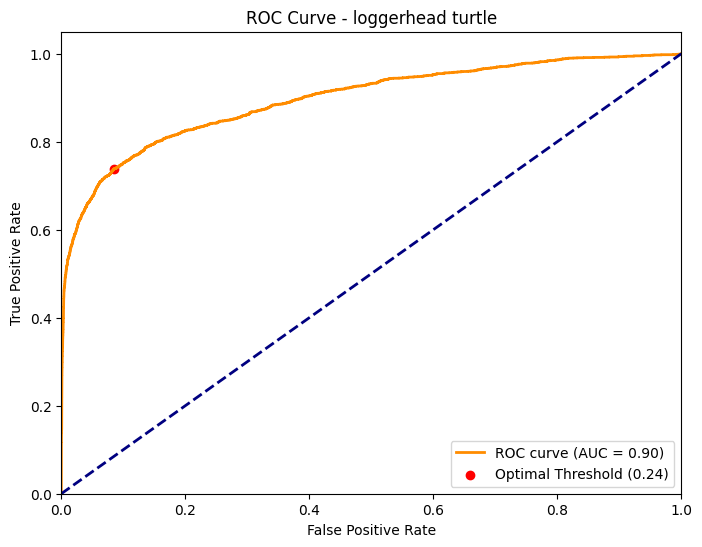


物种 lynx 分析结果:
AUC = 0.6582
最佳阈值 = 0.4499
对应TPR = 32.61%
对应FPR = 4.87%


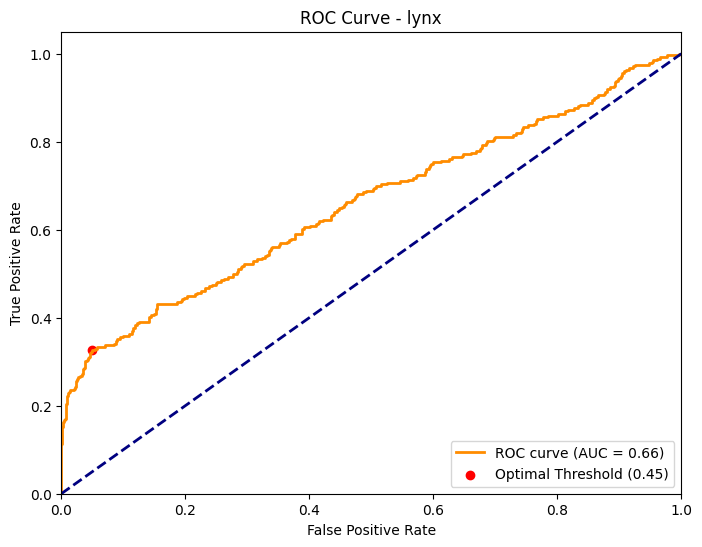


物种 salamander 分析结果:
AUC = 0.9412
最佳阈值 = 0.2723
对应TPR = 86.31%
对应FPR = 7.84%


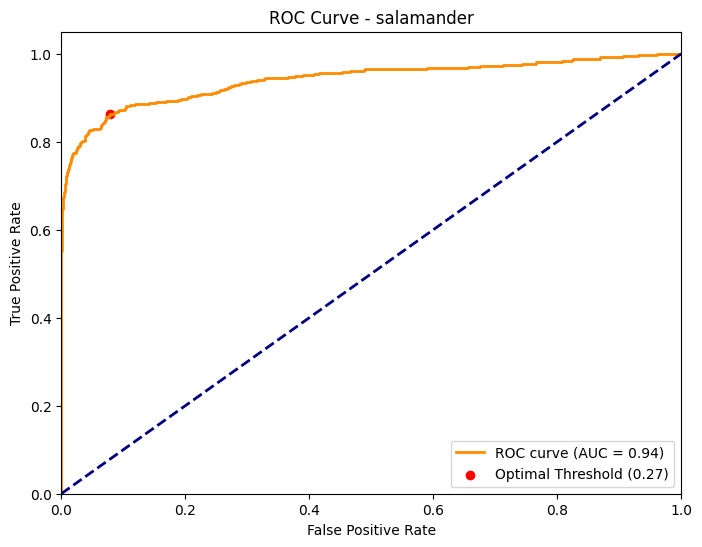

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

def find_optimal_thresholds(species_scores):
    """
    对每个物种计算ROC曲线和最佳阈值
    返回结构：
    {
        'species_A': {
            'fpr': [...],
            'tpr': [...],
            'thresholds': [...],
            'auc': 0.95,
            'optimal_threshold': 0.85,
            'optimal_tpr': 0.90,
            'optimal_fpr': 0.05
        },
        ...
    }
    """
    roc_results = {}
    
    for species, scores in species_scores.items():
        # 合并正负样本分数并生成标签
        y_true = np.concatenate([
            np.ones_like(scores['positive']),  # 正样本标签为1
            np.zeros_like(scores['negative'])  # 负样本标签为0
        ])
        y_score = np.concatenate([scores['positive'], scores['negative']])
        
        # 计算ROC曲线
        fpr, tpr, thresholds = roc_curve(y_true, y_score)
        roc_auc = auc(fpr, tpr)
        
        # 找到最佳阈值（Youden指数）
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = thresholds[optimal_idx]
        
        # 存储结果
        roc_results[species] = {
            'fpr': fpr,
            'tpr': tpr,
            'thresholds': thresholds,
            'auc': roc_auc,
            'optimal_threshold': optimal_threshold,
            'optimal_tpr': tpr[optimal_idx],
            'optimal_fpr': fpr[optimal_idx]
        }
        
        # 打印结果
        print(f"\n物种 {species} 分析结果:")
        print(f"AUC = {roc_auc:.4f}")
        print(f"最佳阈值 = {optimal_threshold:.4f}")
        print(f"对应TPR = {tpr[optimal_idx]:.2%}")
        print(f"对应FPR = {fpr[optimal_idx]:.2%}")
        
        # 绘制ROC曲线
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2,
                 label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.scatter(fpr[optimal_idx], tpr[optimal_idx], marker='o', color='red',
                    label=f'Optimal Threshold ({optimal_threshold:.2f})')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'ROC Curve - {species}')
        plt.legend(loc="lower right")
        plt.show()
    
    return roc_results

# --------------------------------------------------
# 使用示例
roc_results = find_optimal_thresholds(species_scores)


# Testing

In [50]:
# Compute WildFusion similarity
similarity_testSet = wildfusion_submission(testSet, training, B=25)

100%|█████████████████████████████████████████████████████████████| 551/551 [06:19<00:00,  1.45it/s]


In [97]:
import pickle

# 定义要保存的变量（确保这些变量已正确生成）
save_data = {
    "similarity": similarity,  # for thredsholdSet similarity
    "similarity_testSet": similarity_testSet
    #"wildfusion_submission": wildfusion_submission
}

# 保存到 Kaggle 工作目录
with open("/kaggle/working/saved_variables_v13.pkl", "wb") as f:
    pickle.dump(save_data, f)

print("变量已保存到 /kaggle/working/saved_variables_v13.pkl")

变量已保存到 /kaggle/working/saved_variables_v13.pkl


In [51]:
num_not_inf = np.isfinite(similarity_testSet)
similarity_testSet[1,num_not_inf[1,]]

array([0.4815757 , 0.18564606, 0.18032086, 0.19979471, 0.18891221,
       0.17319967, 0.16630854, 0.19498907, 0.1757396 , 0.17074808,
       0.48748666, 0.17284644, 0.33718744, 0.2614339 , 0.16814724,
       0.21463704, 0.17931439, 0.16749266, 0.17523335, 0.18166903,
       0.18720518, 0.19656941, 0.17711657, 0.22654143, 0.2691124 ],
      dtype=float32)

In [52]:
similarity_testSet.shape

(2492, 8802)

In [53]:
similarity_testSet.argsort(axis=1)[:,-1].shape

(2492,)

In [54]:
n_query = len(testSet)
pred_idx = similarity_testSet.argsort(axis=1)[:,-1]
pred_scores = similarity_testSet[range(n_query), pred_idx]

In [55]:
# 使用物种特定阈值进行预测
new_individual = 'new_individual'
predictions = [] 
species_thresholds = {'lynx':0.6,'salamander':0.5,'loggerhead turtle':0.45}
for i, (score, idx) in enumerate(zip(pred_scores, pred_idx)):
    query_species = testSet.metadata.iloc[i]['species']
    threshold = species_thresholds.get(query_species, 0.6)
    
    if score < threshold:
        predictions.append("new_individual")
    else:
        # 确保索引在范围内
        if 0 <= idx < len(training.metadata):
            predictions.append(training.metadata.iloc[idx]['identity'])
        else:
            predictions.append("new_individual")

In [56]:
unseen_ids = []
all_ids = df_database['identity'].unique()

for i in all_ids:
    if i in testSet.metadata['identity'].tolist():
        if i not in training.metadata['identity'].tolist():
            # if not in the training set, the id in test set havent been seen before
            unseen_ids.append(i)

In [57]:
testSet_true_labels = testSet.labels_string.astype(int)
# val_true_labels contains two kinds of labels: in train or not in train 
baks_score = baks_compute(testSet_true_labels, predictions, unseen_ids)
baus_score = baus_compute(testSet_true_labels, predictions, unseen_ids, "new_individual")
geo_mean = compute_geometric_mean(baks_score, baus_score)

print(f"Balanced Accuracy Known Samples (BAKS): {baks_score:.4f}")
print(f"Balanced Accuracy Unknown Samples (BAUS): {baus_score:.4f}")
print(f"Geometric Mean (BAKS & BAUS): {geo_mean:.4f}")

Balanced Accuracy Known Samples (BAKS): 0.5132
Balanced Accuracy Unknown Samples (BAUS): 0.9339
Geometric Mean (BAKS & BAUS): 0.6923


In [15]:
model.load_state_dict(torch.load('/kaggle/working/saved_models_v8/best_model.pth'))

/tmp/ipykernel_1303/527431824.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/kaggle/working/saved_models_v8/best_model.pth'))


<All keys matched successfully>

In [ ]:
# 获取最后一层的权重
for name, param in model.named_parameters():
    if 'fc' in name or 'classifier' in name:  # 根据你的模型结构调整关键字
        print(f"Layer: {name}")
        print(f"Weights shape: {param.shape}")
        print(f"Weights: {param.data}")

In [18]:
model = model.to(device)  
test_input = torch.ones(1, 3, 384, 384)
test_input = test_input.to(device)
with torch.no_grad():
    test_output = model(test_input)
print(test_output.shape)

torch.Size([1, 912])


In [ ]:
print(model)